In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
%%writefile data_pipeline.py


"""
data_pipeline.py -- PIPELINE A: raw documents -> token shards (run ONCE).

Responsibilities:
  SETUP    Tokenizer, Config (shared vocab/model sizes)
  STAGE 0  RawCorpus   -- load raw text documents from a folder
  STAGE 1  ShardWriter -- tokenize docs -> token shards saved to disk
  STAGE 2  ShardStream -- load a token budget of shards into RAM -> batches

Run once (offline):
    python data_pipeline.py

Tokens are pre-tokenized and SAVED here, never tokenized on the fly.
learn_pipeline.py starts from the shards this produces.
"""

import os
import glob

import numpy as np
from tokenizers import ByteLevelBPETokenizer


# where the trained BPE lives, what it trains on, and the target vocab size
BPE_DIR = "data/bpe"
RAW_DIR = "data/raw"
VOCAB_SIZE = 4000        # target; actual may be smaller on a tiny corpus


# ---- SETUP -----------------------------------------------------------------
class Tokenizer:
    """Byte-level BPE trained on YOUR corpus (small vocab -> small embeddings).

    First construction trains the BPE from RAW_DIR and saves it to BPE_DIR;
    later constructions just load it. PAD/EOS are reserved ids just past the
    learned vocab (so the model sizes its embedding to V = vocab + 2).
    """

    def __init__(self, bpe_dir=BPE_DIR, raw_dir=RAW_DIR, vocab_size=VOCAB_SIZE):
        vocab_json = os.path.join(bpe_dir, "vocab.json")
        merges_txt = os.path.join(bpe_dir, "merges.txt")
        if not (os.path.exists(vocab_json) and os.path.exists(merges_txt)):
            self._train(bpe_dir, raw_dir, vocab_size)
        self.bpe = ByteLevelBPETokenizer(vocab_json, merges_txt)
        n = self.bpe.get_vocab_size()
        self.PAD = n          # reserved ids just past the learned vocab
        self.EOS = n + 1
        self.V = n + 2        # total vocab the model must size its embedding to

    def _train(self, bpe_dir, raw_dir, vocab_size):
        files = sorted(glob.glob(os.path.join(raw_dir, "*.txt")))
        if not files:
            raise SystemExit(f"no .txt in {raw_dir}/ to train the BPE on")
        total_mb = sum(os.path.getsize(f) for f in files) / 1e6
        print(f"[BPE] training on {len(files)} files ({total_mb:.1f} MB), "
              f"target vocab {vocab_size} ...", flush=True)
        os.makedirs(bpe_dir, exist_ok=True)
        bpe = ByteLevelBPETokenizer()
        # min_frequency=1 lets it keep merging until it HITS vocab_size exactly
        bpe.train(files=files, vocab_size=vocab_size, min_frequency=1)
        bpe.save_model(bpe_dir)
        got = bpe.get_vocab_size()
        print(f"[BPE] done: {got} tokens (target {vocab_size}) -> {bpe_dir}/", flush=True)
        if got < vocab_size:
            print(f"[BPE] WARNING: only {got} < {vocab_size} -- corpus too small", flush=True)

    def encode(self, text):
        return self.bpe.encode(text).ids

    def decode(self, ids):
        ids = [i for i in ids if i not in (self.PAD, self.EOS)]
        return self.bpe.decode(ids)

    def piece(self, i):
        if i == self.PAD: return "<pad>"
        if i == self.EOS: return "<eos>"
        return self.bpe.decode([i])


class Config:
    def __init__(self):
        self.TOK = Tokenizer()
        self.V = self.TOK.V  # vocabulary size (from the BPE tokenizer)
        self.T = 256     # context window (fits a whole TinyStory ~200 tok)
        self.D = 256     # model dimension
        self.H = 8      # number of attention heads
        self.HD = self.D // self.H  # head dimension
        self.DFF = self.D*4  # feed-forward dimension
        self.L = 6      # number of layers


# ---- STAGE 0: load raw documents ------------------------------------------
class RawCorpus:
    """A folder of raw text files; each file is one document.

    Drop your own .txt files into `folder` (one document per file) and the
    rest of the pipeline picks them up. docs() streams files lazily so the
    whole corpus never needs to sit in RAM.
    """

    def __init__(self, folder, pattern="*.txt"):
        self.folder = folder
        self.pattern = pattern

    def paths(self):
        return sorted(glob.glob(os.path.join(self.folder, self.pattern)))

    def docs(self):
        for p in self.paths():
            with open(p, "r", encoding="utf-8") as f:
                yield f.read()

    def __len__(self):
        return len(self.paths())


# ---- STAGE 1: tokenize -> token shards on disk (run once) -----------------
class ShardWriter:
    """Tokenize a corpus -> fixed-size train/val shards.

    Each shard i -> two parallel files under out_dir/<split>/:
        shard_{i}.tok.npy  token ids (uint16)
        shard_{i}.doc.npy  doc ids   (uint32)  -> lets the trainer rebuild the
                                                   cross-document attention mask.
    Real pipelines use ~100M tokens/shard; we keep it tiny to see the mechanics.
    """

    TOKEN_DTYPE = np.uint16
    DOCID_DTYPE = np.uint32

    def __init__(self, tokenizer, out_dir="data/shards", shard_size=1000,
                 val_frac=0.1):
        self.tok = tokenizer
        self.out_dir = out_dir
        self.shard_size = shard_size
        self.val_frac = val_frac

    def _write_split(self, docs, split):
        split_dir = os.path.join(self.out_dir, split)
        os.makedirs(split_dir, exist_ok=True)
        tok_buf, doc_buf, idx = [], [], 0

        def flush(tok_buf, doc_buf, idx):
            base = os.path.join(split_dir, f"shard_{idx:05d}")
            np.save(base + ".tok.npy", np.array(tok_buf, dtype=self.TOKEN_DTYPE))
            np.save(base + ".doc.npy", np.array(doc_buf, dtype=self.DOCID_DTYPE))
            print(f"  {split}/shard_{idx:05d}  {len(tok_buf):>6} tokens")

        for d, text in enumerate(docs):
            ids = self.tok.encode(text) + [self.tok.EOS]   # EOS separates docs
            tok_buf.extend(ids)
            doc_buf.extend([d] * len(ids))
            while len(tok_buf) >= self.shard_size:         # emit full shards
                flush(tok_buf[:self.shard_size], doc_buf[:self.shard_size], idx)
                tok_buf = tok_buf[self.shard_size:]
                doc_buf = doc_buf[self.shard_size:]
                idx += 1
        if tok_buf:                                        # final partial shard
            flush(tok_buf, doc_buf, idx)
        return sorted(glob.glob(os.path.join(split_dir, "shard_*.tok.npy")))

    def build(self, corpus):
        docs = list(corpus.docs())
        n_val = max(1, int(len(docs) * self.val_frac))
        val_docs, train_docs = docs[:n_val], docs[n_val:]
        print(f"docs: {len(train_docs)} train / {len(val_docs)} val")
        print("writing train shards:")
        train_paths = self._write_split(train_docs, "train")
        print("writing val shards:")
        val_paths = self._write_split(val_docs, "val")
        print(f"done: {len(train_paths)} train + {len(val_paths)} val shards")
        return train_paths, val_paths


# ---- STAGE 2: load a token budget of shards into RAM -> batches -----------
class ShardStream:
    """Stream (tokens, doc_id) (B, T) batches from a split's shards.

    - Loads only as many shards as needed to reach max_tokens (None = all),
      straight into RAM ONCE. 50M tokens = ~100 MB tokens + ~200 MB doc ids.
      After that, every batch is pure in-memory indexing: no file opens.
    - Non-overlapping blocks: the loaded tokens are cut into back-to-back
      T-length blocks so no token window is ever reused.
    - Rank partition: all ranks share one seed -> identical global block shuffle,
      then rank r takes blocks[r::world_size] -> disjoint data, no overlap.
    - Defaults rank=0/world_size=1 -> single process gets ALL blocks.
    - Yields numpy int64 arrays; the trainer wraps them in torch tensors.
    """

    def __init__(self, split_dir, B, T, seed=0, max_tokens=None, max_shards=None,
                 rank=0, world_size=1):
        paths = sorted(glob.glob(os.path.join(split_dir, "shard_*.tok.npy")))
        if max_shards is not None:                 # None = all shards; int = first N
            paths = paths[:max_shards]
        if not paths:
            raise SystemExit(f"no shards in {split_dir}/")

        toks, docs, have = [], [], 0
        for p in paths:                            # stop once the budget is met
            if max_tokens is not None and have >= max_tokens:
                break
            toks.append(np.load(p))
            docs.append(np.load(p.replace(".tok.npy", ".doc.npy")))
            have += len(toks[-1])
        self.toks = np.concatenate(toks)
        self.docs = np.concatenate(docs)
        if max_tokens is not None:                 # trim to the exact budget
            self.toks = self.toks[:max_tokens]
            self.docs = self.docs[:max_tokens]

        self.B, self.T = B, T
        self.rank, self.world_size = rank, world_size
        self.rng = np.random.default_rng(seed)     # SHARED across ranks (same seed)
        self.n_blocks = len(self.toks) // T        # global block id runs 0..n_blocks-1
        self.offsets = np.arange(T)
        print(f"{split_dir}: {len(toks)} shards, {len(self.toks):,} tokens, "
              f"{self.n_blocks:,} blocks", flush=True)

    def _batch(self, block_ids):
        idx = block_ids[:, None] * self.T + self.offsets   # (B, T) positions
        return self.toks[idx].astype(np.int64), self.docs[idx].astype(np.int64)

    def epoch(self):
        order = self.rng.permutation(self.n_blocks)      # same on all ranks (shared seed)
        mine = order[self.rank::self.world_size]          # disjoint stride partition
        for i in range(0, len(mine) - self.B + 1, self.B):
            yield self._batch(mine[i:i + self.B])         # one vectorized gather

    def iter_batches(self):
        """Infinite stream: loop epochs forever (for a fixed step budget)."""
        while True:
            yield from self.epoch()


def preprocess_to_shards(cfg, raw_dir="data/raw", shard_dir="data/shards",
                         shard_size=1000, val_frac=0.1, overwrite=False):
    """One-time preprocess: read the raw folder and write token shards.

    Skips if shards already exist (pass overwrite=True to force a rebuild).
    """
    have = glob.glob(os.path.join(shard_dir, "train", "shard_*.tok.npy"))
    if have and not overwrite:
        print(f"shards already in {shard_dir}/ -- skip (overwrite=True to rebuild)")
        return
    corpus = RawCorpus(raw_dir)
    if len(corpus) == 0:
        raise SystemExit(f"no .txt files in {raw_dir}/ -- drop documents there first")
    print(f"loaded {len(corpus)} docs from {raw_dir}/")
    ShardWriter(cfg.TOK, out_dir=shard_dir, shard_size=shard_size,
                val_frac=val_frac).build(corpus)


def preprocess_split(cfg, raw_dir, split, shard_dir="data/shards", shard_size=1_000_000):
    """Tokenize ALL docs in raw_dir into shards under shard_dir/<split>/.

    Unlike preprocess_to_shards (which splits ONE folder by val_frac), this writes
    a given folder to a named split -- use it to build train and val from the two
    separate TinyStories files (no leakage, real held-out val).
    """
    corpus = RawCorpus(raw_dir)
    if len(corpus) == 0:
        raise SystemExit(f"no .txt files in {raw_dir}/")
    writer = ShardWriter(cfg.TOK, out_dir=shard_dir, shard_size=shard_size)
    paths = writer._write_split(list(corpus.docs()), split)
    print(f"{split}: {len(paths)} shards from {raw_dir}/")
    return paths


def get_streams(cfg, shard_dir="data/shards", micro_B=4, seed=0,
                train_tokens=50_000_000, val_tokens=None, max_shards=None,
                rank=0, world_size=1):
    """Load token budgets into RAM; return (train_stream, val_stream).

    train_tokens: tokens to load for training (default 50M). None = all shards.
    val_tokens:   tokens to load for validation. None = all val shards.
    max_shards:   optional extra cap on shard count (e.g. 1 for quick debugging).
    rank/world_size: pass the SAME seed on every rank; each rank gets a disjoint
                     slice of blocks. Defaults (0, 1) = single process, all data.
    train_stream: infinite micro-batch iterator for the training loop.
    val_stream:   a callable returning one finite pass over val.
    """
    train = ShardStream(os.path.join(shard_dir, "train"), B=micro_B, T=cfg.T,
                        seed=seed, max_tokens=train_tokens, max_shards=max_shards,
                        rank=rank, world_size=world_size)
    val = ShardStream(os.path.join(shard_dir, "val"), B=micro_B, T=cfg.T,
                      seed=seed + 123, max_tokens=val_tokens, max_shards=max_shards,
                      rank=rank, world_size=world_size)
    return train.iter_batches(), val.epoch


if __name__ == "__main__":
    # Run once (offline): train BPE on data/raw, then raw docs -> token shards.
    # overwrite=True so old (gpt2-tokenized) shards are rebuilt with the new vocab.
    cfg = Config()
    print(f"vocab V = {cfg.V}  (BPE {cfg.V - 2} + PAD + EOS)")
    preprocess_to_shards(cfg, overwrite=True)

Writing data_pipeline.py


In [3]:
%%writefile transformer.py

"""
transformer.py -- PIPELINE B: token shards -> batches -> probabilities.

All DATA handling (tokenizer, shard writing, shard streaming) lives in
data_pipeline.py. This file starts from the streamed batches and turns them
into logits -> probabilities -> loss (the learning half).

    python data_pipeline.py     # once: raw -> token shards
    python transformer.py    # every run: shards -> batches (-> training)
"""

import math
import time

import torch
import torch.nn as nn
import torch.nn.functional as F

from data_pipeline import Config, get_streams, Tokenizer

# build the tokenizer ONCE (module-level); reloading it per make_masks call was
# reading the BPE files off disk every step -> a real per-step slowdown
_TOK = None

def make_masks(tokens,doc_id):
    global _TOK
    if _TOK is None:
        _TOK = Tokenizer()          # first call only; cached thereafter
    TOK = _TOK
    B,T = tokens.shape
    # no peeking into future tokens
    casual = torch.tril(torch.ones(T,T, dtype=torch.bool, device=tokens.device)) # (T,T)
    # only attend to tokens within the same document
    same = doc_id[:,:,None] == doc_id[:,None,:] # (B,T,1) vs (B,1,T) -> (B,T,T)
    # combine causal and same-document masks
    attn = (casual & same).unsqueeze(1) # (B,1,T,T)
    # target tokens (shifted by one)
    tgt = tokens[:,1:]
    # identify positions where the document changes
    join = doc_id[:,1:] != doc_id[:,:-1] # (B,T-1) vs (B,T-1) -> comparing adjacent doc_ids
    # positions where the document changes (to avoid computing loss across document boundaries)
    loss = (tgt != TOK.PAD) & (~join)
    return attn, loss

class RMSNorm(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.d = d
        self.g = nn.Parameter(torch.ones(d))
    def forward(self,x):
        # RMSNorm forward pass
        ms = x.pow(2).mean(-1, keepdim=True) # (B,T,D) -> (B,T,1)
        return x*torch.rsqrt(ms + 1e-6)*self.g

class Attention(nn.Module):
    def __init__(self,c):
        super().__init__()
        self.c = c
        self.q = nn.Linear(c.D, c.D, bias=False)
        self.k = nn.Linear(c.D, c.D, bias=False)
        self.v = nn.Linear(c.D, c.D, bias=False)
        self.out = nn.Linear(c.D, c.D, bias=False)
    def forward(self,x,mask):
        c  = self.c
        B,T,_ = x.shape
        sp = lambda t: t.view(B,T,c.H, c.HD).transpose(1,2)
        # get q,k,v projections for multi-head attention
        q,k,v = sp(self.q(x)), sp(self.k(x)), sp(self.v(x)) # (B,c.H,T,c.HD)
        # multiply queries and keys to get attention scores
        s = (q @ k.transpose(-2,-1)) / (c.HD ** 0.5) # (B,c.H,T,c.HD) @ (B,c.H,c.HD,T) -> (B,c.H,T,T)
        # apply the attention mask to prevent attending to future tokens or tokens from different documents
        s = s.masked_fill(~mask, float('-inf'))
        # softmax to obtain attention weights
        w = torch.nan_to_num(s.softmax(-1))
        # value vectors are combined with attention weights to produce the context vectors
        ctx = (w @ v).transpose(1,2).reshape(B,T,c.D) 
        return self.out(ctx)

class SwiGLU(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.gate = nn.Linear(c.D, c.DFF, bias=False)
        self.up = nn.Linear(c.D, c.DFF, bias=False)
        self.bottom = nn.Linear(c.DFF, c.D, bias=False)
    def forward(self,x):
        return self.bottom(self.up(x) * F.silu(self.gate(x)))

class Block(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.c = c
        self.attn = Attention(c)
        self.n1 = RMSNorm(c.D)
        self.n2 = RMSNorm(c.D)
        self.ffn = SwiGLU(c)
    def forward(self,x,mask):
        x = x + self.attn(self.n1(x), mask)
        x = x + self.ffn(self.n2(x))
        return x


class GPT(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.c = c
        self.tok_emb = nn.Embedding(c.V, c.D)
        self.pos_emb = nn.Embedding(c.T, c.D)
        self.blocks = nn.ModuleList([Block(c) for _ in range(c.L)])
        self.ns = RMSNorm(c.D)
        self.head = nn.Linear(c.D, c.V, bias=False)

    def forward(self,tokens, mask):
        B,T = tokens.shape
        pos = torch.arange(T, device=tokens.device)
        x = self.tok_emb(tokens) + self.pos_emb(pos)
        for blk in self.blocks:
            x = blk(x,mask)
        x = self.ns(x)
        logits = self.head(x)
        return logits

def loss_fn(logits, tokens, loss_mask):
    tgt = tokens[:, 1:].reshape(-1) # (B, T-1) -> (B*(T-1))
    lg = logits[:,:-1].reshape(-1,logits.size(-1)) # (B, T-1, V) -> (B*(T-1), V)
    nll = F.cross_entropy(lg, tgt, reduction='none')
    m = loss_mask.reshape(-1).float()
    loss = (nll * m).sum() / m.sum().clamp(min=1)
    return loss, int(m.sum())

def lr_at(s, WARMUP, STEPS):
    if s < WARMUP:
        return s / WARMUP
    t = (s - WARMUP) / max(1, STEPS - WARMUP)
    return 0.1 + 0.45 * (1 + math.cos(math.pi * t))


# @torch.no_grad()
# def evaluate(model, val_stream, max_batches=20):
#     """Token-weighted mean loss over up to max_batches of the val stream."""
#     model.eval()
#     tot, ntok = 0.0, 0
#     for i, (x, d) in enumerate(val_stream()):        # fresh finite pass
#         if i >= max_batches:
#             break
#         tokens, doc_id = torch.from_numpy(x), torch.from_numpy(d)
#         attn, loss_mask = make_masks(tokens, doc_id)
#         loss, n = loss_fn(model(tokens, attn), tokens, loss_mask)
#         tot += loss.item() * n
#         ntok += n
#     model.train()
#     return tot / max(1, ntok)


# def _trace_shapes(model, tokens, doc_id):
#     """One-time forward pass that prints the output shape of every submodule."""
#     attn, loss_mask = make_masks(tokens, doc_id)
#     print("  inputs:")
#     print(f"    {'tokens':<26} {tuple(tokens.shape)}")
#     print(f"    {'doc_id':<26} {tuple(doc_id.shape)}")
#     print(f"    {'attn mask':<26} {tuple(attn.shape)}")
#     print(f"    {'loss mask':<26} {tuple(loss_mask.shape)}")
#     print("  module outputs:")

#     handles = []
#     def mk(name):
#         def hook(mod, inp, out):
#             if isinstance(out, torch.Tensor):
#                 print(f"    {name:<26} {tuple(out.shape)}")
#         return hook
#     for name, mod in model.named_modules():
#         if name:                                     # skip the root module
#             handles.append(mod.register_forward_hook(mk(name)))
#     with torch.no_grad():
#         logits = model(tokens, attn)
#     for h in handles:
#         h.remove()
#     print(f"    {'logits (head)':<26} {tuple(logits.shape)}")


# def train(STEPS=500, WARMUP=50, lr=3e-4, micro_B=4, accum_steps=4,
#           eval_every=100, log_every=1, max_shards=None, seed=0, debug=True):
#     cfg = Config()
#     torch.manual_seed(seed)

#     # STAGE 2: stream (tokens, doc_id) batches from the saved token shards.
#     train_stream, val_stream = get_streams(cfg, micro_B=micro_B, seed=seed,
#                                            max_shards=max_shards)
#     model = GPT(cfg)
#     opt = torch.optim.AdamW(model.parameters(), lr=lr)
#     print(f"eff. batch {micro_B * accum_steps}  |  ln(V) {math.log(cfg.V):.3f}")

#     if debug:                                        # one-time shape trace
#         x, d = next(train_stream)
#         print("shape trace:")
#         _trace_shapes(model, torch.from_numpy(x), torch.from_numpy(d))

#     seen = 0                                         # cumulative tokens trained on
#     for s in range(STEPS):
#         t0 = time.time()
#         cur_lr = lr * lr_at(s, WARMUP, STEPS)
#         for g in opt.param_groups:                   # LR warmup + cosine decay
#             g['lr'] = cur_lr
#         opt.zero_grad(set_to_none=True)

#         run_loss, step_tok = 0.0, 0
#         for _ in range(accum_steps):                 # accumulate micro-batches
#             x, d = next(train_stream)
#             tokens, doc_id = torch.from_numpy(x), torch.from_numpy(d)
#             attn, loss_mask = make_masks(tokens, doc_id)
#             loss, n = loss_fn(model(tokens, attn), tokens, loss_mask)
#             (loss / accum_steps).backward()          # grads add up; no step yet
#             run_loss, step_tok = run_loss + loss.item() * n, step_tok + n
#         gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         opt.step()                                   # one update per effective batch
#         seen += step_tok

#         if s % log_every == 0:
#             dt = time.time() - t0
#             avg = run_loss / max(1, step_tok)        # token-weighted mean over the step
#             print(f"step {s:4d} | lr {cur_lr:.2e} | loss {avg:.4f} | "
#                   f"gnorm {float(gnorm):.2f} | tok {step_tok} | seen {seen} | "
#                   f"{step_tok / max(dt, 1e-9):.0f} tok/s")
#         if s % eval_every == 0:
#             print(f"           val {evaluate(model, val_stream):.4f}")
#     return model


if __name__ == "__main__":
    # Requires token shards on disk first:  python data_pipeline.py
    # train(STEPS=500, eval_every=50)
    pass

Writing transformer.py


In [4]:
%%writefile moe_pipeline.py

"""
moe_pipeline.py -- the Mixture-of-Experts version of transformer.GPT.

Only ONE thing changes vs the dense model: inside every Block, the single SwiGLU
FFN becomes E SwiGLU experts plus a small router that sends each token to its
top-k experts.

    dense Block:  x + attn(n1(x));  x + ffn(n2(x))
    MoE   Block:  x + attn(n1(x));  x + sum_{e in topk(x)} w_e(x) * expert_e(n2(x))

Attention, norms, embeddings and the head are reused unchanged from transformer.py.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformer import Attention, SwiGLU, RMSNorm


class MoE(nn.Module):
    """Top-k routed SwiGLU experts (dropless: no token is ever dropped)."""

    def __init__(self, c, E=4, k=2):
        super().__init__()
        self.E, self.k = E, k
        self.router = nn.Linear(c.D, E, bias=False)
        self.experts = nn.ModuleList([SwiGLU(c) for _ in range(E)])
        # filled every forward; read by the training loop
        self.aux = None        # load-balancing loss (scalar tensor)
        self.load = None       # fraction of routed slots per expert, shape (E,)

    def forward(self, x):
        B, T, D = x.shape
        xf = x.reshape(-1, D)                                   # (N,D), N=B*T
        # router in fp32 -> probabilities over experts
        probs = self.router(xf).float().softmax(-1)             # (N,E)
        topw, topi = probs.topk(self.k, dim=-1)                 # (N,k) each
        topw = topw / topw.sum(-1, keepdim=True)                # renormalise -> sums to 1

        out = torch.zeros_like(xf)
        for e, expert in enumerate(self.experts):
            # which (token, slot) pairs chose expert e
            tok, slot = (topi == e).nonzero(as_tuple=True)
            # ALWAYS call the expert, even with 0 tokens: keeps every expert in the
            # autograd graph so FSDP gets a (zero) grad for it on every rank
            y = expert(xf[tok])                                 # (n_e,D)
            out.index_add_(0, tok, y * topw[tok, slot, None].to(y.dtype))

        # Switch-style load balancing: E * sum_e f_e * P_e  (=1 when perfectly uniform)
        # f_e = share of routed slots that went to e (no grad), P_e = mean router prob
        f = F.one_hot(topi, self.E).float().sum((0, 1)) / (xf.size(0) * self.k)
        P = probs.mean(0)
        self.aux = self.E * (f * P).sum()
        self.load = f.detach()
        return out.view(B, T, D)


class MoEBlock(nn.Module):
    def __init__(self, c, E=4, k=2):
        super().__init__()
        self.c = c
        self.attn = Attention(c)
        self.n1 = RMSNorm(c.D)
        self.n2 = RMSNorm(c.D)
        self.ffn = MoE(c, E, k)

    def forward(self, x, mask):
        x = x + self.attn(self.n1(x), mask)
        x = x + self.ffn(self.n2(x))
        return x


class MoEGPT(nn.Module):
    """Same as transformer.GPT, but every Block's FFN is an MoE."""

    def __init__(self, c, E=4, k=2):
        super().__init__()
        self.c = c
        self.tok_emb = nn.Embedding(c.V, c.D)
        self.pos_emb = nn.Embedding(c.T, c.D)
        self.blocks = nn.ModuleList([MoEBlock(c, E, k) for _ in range(c.L)])
        self.ns = RMSNorm(c.D)
        self.head = nn.Linear(c.D, c.V, bias=False)

    def forward(self, tokens, mask):
        B, T = tokens.shape
        pos = torch.arange(T, device=tokens.device)
        x = self.tok_emb(tokens) + self.pos_emb(pos)
        for blk in self.blocks:
            x = blk(x, mask)
        x = self.ns(x)
        return self.head(x)


def moe_layers(model):
    return [m for m in model.modules() if isinstance(m, MoE)]


def aux_loss(model):
    """Mean load-balancing loss over all MoE layers of the last forward."""
    layers = moe_layers(model)
    return sum(m.aux for m in layers) / len(layers)


def expert_load(model):
    """(L,E) tensor: per-layer share of routed slots each expert got."""
    return torch.stack([m.load for m in moe_layers(model)])


def param_counts(model, E, k):
    """(total, active-per-token) parameter counts for an MoEGPT."""
    total = sum(p.numel() for p in model.parameters())
    expert = sum(p.numel() for m in moe_layers(model) for p in m.experts.parameters())
    active = total - expert + expert * k // E
    return total, active

Writing moe_pipeline.py


In [5]:
%%writefile zero3_launch.py

# Session 14 DENSE run: ~20M GPT trained from scratch with ZeRO-3.
# Twin of moe_launch.py: same data, batch, steps, LR, seed -- only the FFN differs.
#   torchrun --nproc_per_node=2 zero3_launch.py


# read env vars torchrun injects
import os
# csv metrics logging + step timing
import csv
import time
import math
# add the Kaggle dataset folder to the import path
import sys
# for torch.cuda.set_device
import torch
# collectives: init/all_reduce/broadcast
import torch.distributed as dist
# ZeRO-3 engine: shards params + grads + optimizer, gathers layer-by-layer
from torch.distributed.fsdp import FullyShardedDataParallel as FSDP
from torch.distributed.fsdp import ShardingStrategy
# gathering the sharded model back into one full state dict for the checkpoint
from torch.distributed.fsdp import StateDictType, FullStateDictConfig
from torch.distributed.fsdp.wrap import ModuleWrapPolicy

# dataset root holds the loose .py files; add it to the import path
SRC = "/kaggle/input/datasets/gona26/tinystories-data-540m"
# shards + bpe live under this subfolder
DATA = f"{SRC}/"
sys.path.insert(0, SRC)
# this script's folder FIRST, so data_pipeline.py / transformer.py next to it win
sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
# model/vocab sizes + the data stream factory
from data_pipeline import Config, get_streams
# model + a Block (the unit we shard) + RMSNorm (needs custom init) + helpers
from transformer import GPT, Block, RMSNorm, make_masks, loss_fn, lr_at


def setup():
    # CPU: read this process's GPU index that torchrun injected (str -> int)
    local_rank = int(os.environ["LOCAL_RANK"])
    # GPU: pin this process to that one GPU (must happen before init)
    torch.cuda.set_device(local_rank)
    # GPU<->GPU: join the process group; device_id tells NCCL our GPU
    dist.init_process_group(
        backend="nccl",
        device_id=torch.device(f"cuda:{local_rank}"),
    )
    # CPU: return identity read back from the group
    return dist.get_rank(), dist.get_world_size(), local_rank


def print0(rank, *args):
    if rank == 0:
        print(*args, flush=True)


def model_info(model, cfg):
    P = sum(p.numel() for p in model.parameters())    # numel works on meta tensors too
    emb = 2 * cfg.V * cfg.D
    return (f"model: {P/1e6:.2f}M params | L={cfg.L} D={cfg.D} H={cfg.H} "
            f"T={cfg.T} V={cfg.V} | embed+head ~{emb/1e6:.1f}M ({100*emb/P:.0f}%)")


def measure_holdings(model, opt):
    # actual bytes from live tensors; under FSDP these are the LOCAL shards (1/N)
    mb = lambda ts: sum(t.numel() * t.element_size() for t in ts) / 1e6
    params_mb = mb(list(model.parameters()))
    grads_mb = mb([p.grad for p in model.parameters() if p.grad is not None])
    optim_mb = mb([t for st in opt.state.values() for t in st.values() if torch.is_tensor(t)])
    return params_mb, grads_mb, optim_mb


def param_init_fn(module):
    # FSDP calls this per module while sharding, to bring META tensors to life:
    # allocate real (uninitialized) tensors on THIS process's GPU...
    module.to_empty(device=torch.cuda.current_device(), recurse=False)
    # ...then set proper initial values (meta tensors carried none)
    with torch.no_grad():
        if isinstance(module, RMSNorm):
            module.g.fill_(1.0)                 # RMSNorm gain starts at 1
        elif hasattr(module, "reset_parameters"):
            module.reset_parameters()           # Linear/Embedding default init


@torch.no_grad()
def evaluate(model, val_stream, device, max_batches):
    """Token-weighted mean loss over up to max_batches of the held-out val set,
    summed across ranks -> a true GLOBAL validation loss (perplexity = e^loss)."""
    model.eval()
    tot = torch.zeros(2, device=device)              # [sum loss*tok, sum tok]
    for i, (x, d) in enumerate(val_stream()):
        if i >= max_batches:
            break
        tokens = torch.from_numpy(x).to(device)
        doc_id = torch.from_numpy(d).to(device)
        attn, loss_mask = make_masks(tokens, doc_id)
        loss, n = loss_fn(model(tokens, attn), tokens, loss_mask)
        tot[0] += loss.item() * n
        tot[1] += n
    dist.all_reduce(tot)                             # GPU<->GPU: global sums
    model.train()
    return (tot[0] / tot[1].clamp(min=1)).item()


def main():
    rank, world_size, local_rank = setup()
    device = torch.device(f"cuda:{local_rank}")
    print(f"rank {rank}/{world_size} on cuda:{local_rank}  \n", flush=True)

    # ---- data: disjoint blocks per rank (shared seed) ----
    # CPU: Config builds tokenizer; the stream reads shards into numpy (numpy = CPU RAM)
    cfg = Config()
    # guarantee the ~19.6M ("20M") config no matter which data_pipeline is uploaded
    cfg.D, cfg.H, cfg.L = 384, 8, 7
    cfg.T = 256                                    # longer context (fits a whole story)
    cfg.HD, cfg.DFF = cfg.D // cfg.H, cfg.D * 4
    # 64 in BOTH dense and MoE runs: the MoE (top-2 -> ~2x FFN activations) OOMs at 120
    micro_B = 64
    # ---- token budget: the ONE knob; everything below derives from it ----
    TRAIN_TOKENS = 55_000_000                     # unique train tokens loaded into RAM
    # CPU: sets up the numpy batch iterators (no GPU touched here); keep val too
    train_stream, val_stream = get_streams(cfg, shard_dir=f"{DATA}/shards",
                                       micro_B=micro_B, seed=1234,
                                       train_tokens=TRAIN_TOKENS,
                                       val_tokens=None,
                                       rank=rank, world_size=world_size)

    # STEPS = one pass over the budget: TRAIN_TOKENS / (T * micro_B * world_size)
    # (floor -> never spills into a 2nd epoch; adapts to any world_size)
    STEPS = TRAIN_TOKENS // (cfg.T * micro_B * world_size)
    WARMUP, base_lr, LOG_EVERY = 300, 3e-4, 50
    print0(rank, f"budget {TRAIN_TOKENS/1e6:.0f}M tok | {STEPS} steps x "
                 f"{cfg.T}T x {micro_B}B x {world_size} ranks")
    # val ppl on every log line; 20 batches x B x T x ranks (~164k tok on 2 GPUs)
    # keeps eval overhead ~10-15% of training time (50 batches would be ~30%)
    EVAL_EVERY, EVAL_BATCHES = LOG_EVERY, 20
    torch.manual_seed(0)
    # META init: build the model with SHAPES ONLY -> ZERO bytes allocated, so the full
    # model never lands on any single GPU (this is what avoids OOM for huge models).
    with torch.device("meta"):
        model = GPT(cfg)
    print0(rank, model_info(model, cfg))

    # ---- ZeRO-3: shard params across ranks; FSDP materializes only each rank's 1/N ----
    # GPU: FULL_SHARD = ZeRO-3 (params + grads + optimizer sharded). param_init_fn builds
    # + inits each shard on the GPU, so the whole model is never assembled in one place.
    # (SHARD_GRAD_OP would be ZeRO-2; NO_SHARD would be plain DDP.)
    model = FSDP(
        model,
        # each Block is gathered/freed on its own -> peak memory = ~one Block
        auto_wrap_policy=ModuleWrapPolicy({Block}),
        sharding_strategy=ShardingStrategy.FULL_SHARD,
        device_id=local_rank,
        param_init_fn=param_init_fn,
    )
    # CPU setup over GPU-resident sharded params: MUST be built AFTER FSDP so it sees
    # the sharded (flat) params; its m/v state is allocated on GPU at first step, 1/N size
    opt = torch.optim.AdamW(model.parameters(), lr=base_lr)
    print0(rank, model)

    # one timestamp per run -> every run writes NEW files, never overwrites old ones
    # (only rank 0 writes files, so only rank 0's clock matters)
    RUN_ID = time.strftime("%Y%m%d_%H%M%S")
    OUT_DIR = "/kaggle/working"
    metrics_path = f"{OUT_DIR}/metrics_zero3_{RUN_ID}.csv"
    holdings_path = f"{OUT_DIR}/holdings_zero3_{RUN_ID}.csv"

    if rank == 0:
        print(f"run {RUN_ID} -> {metrics_path}", flush=True)
        logf = open(metrics_path, "w", newline="")
        writer = csv.writer(logf)
        writer.writerow(["step", "tokens", "loss_tokens", "loss", "ppl", "val_loss",
                         "val_ppl", "grad_norm", "tok_per_s", "lr",
                         "alloc_mb", "peak_mb", "reserved_mb", "gpu_used_mb", "gpu_total_mb"])

    # token counters, built from the ACTUAL batch shapes (not assumed T*B)
    local_seen = 0          # this rank: positions fed to the model (B*T per batch)
    local_trained = 0.0     # this rank: positions that counted in the loss (n)
    win_tok, win_t0 = 0, time.time()   # window since last log -> steady tok/s
    for s in range(1, STEPS + 1):
        # CPU: schedule math (plain floats), then push the LR onto the optimizer
        cur_lr = base_lr * lr_at(s, WARMUP, STEPS)
        for g in opt.param_groups:
            g['lr'] = cur_lr
        # CPU: pull one numpy micro-batch off the stream
        x, d = next(train_stream)
        # CPU: verify every sequence is exactly T long, then count what we really got
        assert x.shape == (micro_B, cfg.T) and d.shape == x.shape, \
            f"step {s}: bad batch shape tok={x.shape} doc={d.shape}"
        local_seen += x.shape[0] * x.shape[1]      # rows x sequence length
        win_tok += x.shape[0] * x.shape[1]
        # CPU->GPU: numpy -> GPU tensors (from_numpy is CPU, .to(device) copies over)
        tokens = torch.from_numpy(x).to(device)
        doc_id = torch.from_numpy(d).to(device)
        # GPU: build the attention/loss masks on the data's device
        attn, loss_mask = make_masks(tokens, doc_id)
        # GPU (+ GPU<->GPU comms): FSDP forward all_gathers each Block's full params
        # just-in-time, runs it, then FREES them -> peak memory ~ one Block
        loss, n = loss_fn(model(tokens, attn), tokens, loss_mask)
        # GPU: running count of positions that actually got a loss (stays on GPU,
        # no .item() here -> no per-step CPU/GPU sync)
        local_trained += n
        # GPU: drop stale grads
        opt.zero_grad(set_to_none=True)
        # GPU (+ comms): backward gathers params again, computes grads, then
        # reduce_scatters them -> each rank KEEPS ONLY ITS SHARD of the gradients
        loss.backward()
        # GPU (+ comms): FSDP-aware global grad-norm clip; returns the total norm
        gnorm = model.clip_grad_norm_(1.0)
        # GPU: each rank updates ONLY its param shard (no manual all_reduce/broadcast)
        opt.step()

        if s % LOG_EVERY == 0 or s == STEPS:          # always log the final step too
            # GPU<->GPU: one all_reduce for everything we sum across ranks:
            # [loss*n this step, n this step, total seen, total trained, window tokens]
            stats = torch.tensor([loss.item() * float(n), float(n), float(local_seen),
                                  float(local_trained), float(win_tok)],
                                 device=device, dtype=torch.float64)
            dist.all_reduce(stats)
            # GPU->CPU: .item() pulls the scalars back to host for printing/logging
            avg_loss = (stats[0] / stats[1]).item()
            ppl = math.exp(min(avg_loss, 20))            # train perplexity = e^loss
            seen = int(stats[2].item())                  # global positions fed (all ranks)
            trained = int(stats[3].item())               # global positions scored by loss
            # CPU: steady throughput over the whole window, not one noisy step
            win_dt = time.time() - win_t0
            tps = stats[4].item() / max(win_dt, 1e-9)
            eta_min = (STEPS - s) * (win_dt / LOG_EVERY) / 60

            # GPU memory, 4 levels (each contains the one before), read BEFORE eval so
            # the numbers describe training only:
            #   alloc  = tensors alive right now
            #   peak   = highest tensor usage in this window (reset after each log)
            #   resv   = what PyTorch has claimed from the GPU (incl. its free cache)
            #   used   = GPU's own view (like nvidia-smi): + CUDA context + NCCL buffers
            free_b, total_b = torch.cuda.mem_get_info()
            mem = torch.tensor([torch.cuda.memory_allocated(),
                                torch.cuda.max_memory_allocated(),
                                torch.cuda.memory_reserved(),
                                total_b - free_b, total_b],
                               device=device, dtype=torch.float64) / 1e6
            # GPU<->GPU: MAX across ranks -> report the fullest GPU, not just rank 0
            dist.all_reduce(mem, op=dist.ReduceOp.MAX)
            alloc_mb, peak_mb, resv_mb, used_mb, total_mb = mem.tolist()

            # held-out validation perplexity (the real-world quality signal)
            val_loss = val_ppl = ""
            if s % EVAL_EVERY == 0 or s == STEPS:
                vl = evaluate(model, val_stream, device, EVAL_BATCHES)
                val_loss, val_ppl = f"{vl:.4f}", f"{math.exp(min(vl, 20)):.2f}"

            if rank == 0:
                # CPU: write the row to disk
                writer.writerow([s, seen, trained, f"{avg_loss:.4f}", f"{ppl:.2f}",
                                 val_loss, val_ppl, f"{float(gnorm):.2f}",
                                 f"{tps:.0f}", f"{cur_lr:.2e}",
                                 f"{alloc_mb:.0f}", f"{peak_mb:.0f}", f"{resv_mb:.0f}",
                                 f"{used_mb:.0f}", f"{total_mb:.0f}"])
                logf.flush()
                msg = (f"step {s:5d}/{STEPS} | {seen/1e6:6.1f}M tok "
                       f"({trained/1e6:.1f}M in loss) | "
                       f"loss {avg_loss:.4f} ppl {ppl:.1f}")
                if val_ppl:
                    msg += f" | val_ppl {val_ppl}"
                msg += (f" | gnorm {float(gnorm):.2f} | {tps:.0f} tok/s | "
                        f"mem peak {peak_mb:.0f} / resv {resv_mb:.0f} / "
                        f"gpu {used_mb:.0f} of {total_mb:.0f}MB | eta {eta_min:.0f}m")
                print(msg, flush=True)

            # reset the throughput window AND the peak counter AFTER eval/print, so the
            # next window's tok/s and peak memory describe training steps only
            win_tok, win_t0 = 0, time.time()
            torch.cuda.reset_peak_memory_stats()

    # final token audit: counted tokens must equal the budget math
    total = torch.tensor([float(local_seen)], device=device, dtype=torch.float64)
    dist.all_reduce(total)
    expected = STEPS * cfg.T * micro_B * world_size
    print0(rank, f"token audit: counted {int(total.item()):,} | expected {expected:,} | "
                 f"budget {TRAIN_TOKENS:,}")

    if rank == 0:
        logf.close()

    # ---- save a checkpoint for inference ----
    # Under ZeRO-3 no rank holds the whole model, so FSDP must GATHER it first.
    # FULL_STATE_DICT = reassemble every shard into normal (un-sharded) weights with
    # the original parameter names; rank0_only + offload_to_cpu = only rank 0 keeps
    # the result, in CPU RAM (so no GPU ever holds a second full copy).
    # EVERY rank must call state_dict() -- it's a collective (all ranks send shards).
    save_cfg = FullStateDictConfig(offload_to_cpu=True, rank0_only=True)
    with FSDP.state_dict_type(model, StateDictType.FULL_STATE_DICT, save_cfg):
        full_state = model.state_dict()
    if rank == 0:
        ckpt_path = f"{OUT_DIR}/ckpt_zero3_{RUN_ID}.pt"
        torch.save({
            "model": full_state,
            # the exact shape knobs used here (they were overridden above), so
            # inference rebuilds the SAME architecture without guessing
            "cfg": {"V": cfg.V, "T": cfg.T, "D": cfg.D, "H": cfg.H,
                    "HD": cfg.HD, "DFF": cfg.DFF, "L": cfg.L},
            "run_id": RUN_ID, "steps": STEPS, "train_tokens": TRAIN_TOKENS,
        }, ckpt_path)
        print(f"saved checkpoint -> {ckpt_path}", flush=True)

    # per-rank holdings: params + grads + optim should ALL be ~1/world_size now
    params_mb, grads_mb, optim_mb = measure_holdings(model, opt)
    print(f"rank {rank} holdings: params {params_mb:.0f}MB grads {grads_mb:.0f}MB "
          f"optim {optim_mb:.0f}MB total {params_mb+grads_mb+optim_mb:.0f}MB", flush=True)
    if rank == 0:
        with open(holdings_path, "w", newline="") as hf:
            w = csv.writer(hf)
            w.writerow(["component", "mb"])
            w.writerow(["params", f"{params_mb:.2f}"])
            w.writerow(["grads", f"{grads_mb:.2f}"])
            w.writerow(["optimizer", f"{optim_mb:.2f}"])

    dist.barrier()
    print0(rank, "done")
    dist.destroy_process_group()


if __name__ == "__main__":
    main()

# ---- after BOTH runs, compare (normal notebook cell) ----
#   from plot_moe import compare
#   compare("/kaggle/working/metrics_zero3_<RUN_ID>.csv",
#           "/kaggle/working/metrics_moe_<RUN_ID>.csv", "/kaggle/working/plots")

Writing zero3_launch.py


In [6]:
%%writefile moe_launch.py

# Session 14 MoE run: same GPT, but every FFN is a 4-expert top-2 MoE, trained from
# scratch with ZeRO-3. Twin of zero3_launch.py -- every change is marked '# MoE'.
#   torchrun --nproc_per_node=2 moe_launch.py
#   diff zero3_launch.py moe_launch.py      # shows exactly what dense -> MoE adds


# read env vars torchrun injects
import os
# csv metrics logging + step timing
import csv
import time
import math
# add the Kaggle dataset folder to the import path
import sys
# for torch.cuda.set_device
import torch
# collectives: init/all_reduce/broadcast
import torch.distributed as dist
# ZeRO-3 engine: shards params + grads + optimizer, gathers layer-by-layer
from torch.distributed.fsdp import FullyShardedDataParallel as FSDP
from torch.distributed.fsdp import ShardingStrategy
# gathering the sharded model back into one full state dict for the checkpoint
from torch.distributed.fsdp import StateDictType, FullStateDictConfig
from torch.distributed.fsdp.wrap import ModuleWrapPolicy

# dataset root holds the loose .py files; add it to the import path
SRC = "/kaggle/input/datasets/gona26/tinystories-data-540m"
# shards + bpe live under this subfolder
DATA = f"{SRC}/"
sys.path.insert(0, SRC)
# this script's folder FIRST, so data_pipeline.py / transformer.py next to it win
sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
# model/vocab sizes + the data stream factory
from data_pipeline import Config, get_streams
# model + a Block (the unit we shard) + RMSNorm (needs custom init) + helpers
from transformer import RMSNorm, make_masks, loss_fn, lr_at
# MoE: the model + its block (the unit we shard) + routing stats
from moe_pipeline import MoEGPT, MoEBlock, aux_loss, expert_load, param_counts

# MoE: knobs
E, TOP_K = 4, 2           # 4 experts per block, each token uses 2 of them
AUX_COEF = 0.01           # weight of the load-balancing loss


def setup():
    # CPU: read this process's GPU index that torchrun injected (str -> int)
    local_rank = int(os.environ["LOCAL_RANK"])
    # GPU: pin this process to that one GPU (must happen before init)
    torch.cuda.set_device(local_rank)
    # GPU<->GPU: join the process group; device_id tells NCCL our GPU
    dist.init_process_group(
        backend="nccl",
        device_id=torch.device(f"cuda:{local_rank}"),
    )
    # CPU: return identity read back from the group
    return dist.get_rank(), dist.get_world_size(), local_rank


def print0(rank, *args):
    if rank == 0:
        print(*args, flush=True)


def model_info(model, cfg):
    P = sum(p.numel() for p in model.parameters())    # numel works on meta tensors too
    emb = 2 * cfg.V * cfg.D
    return (f"model: {P/1e6:.2f}M params | L={cfg.L} D={cfg.D} H={cfg.H} "
            f"T={cfg.T} V={cfg.V} | embed+head ~{emb/1e6:.1f}M ({100*emb/P:.0f}%)")


def measure_holdings(model, opt):
    # actual bytes from live tensors; under FSDP these are the LOCAL shards (1/N)
    mb = lambda ts: sum(t.numel() * t.element_size() for t in ts) / 1e6
    params_mb = mb(list(model.parameters()))
    grads_mb = mb([p.grad for p in model.parameters() if p.grad is not None])
    optim_mb = mb([t for st in opt.state.values() for t in st.values() if torch.is_tensor(t)])
    return params_mb, grads_mb, optim_mb


def param_init_fn(module):
    # FSDP calls this per module while sharding, to bring META tensors to life:
    # allocate real (uninitialized) tensors on THIS process's GPU...
    module.to_empty(device=torch.cuda.current_device(), recurse=False)
    # ...then set proper initial values (meta tensors carried none)
    with torch.no_grad():
        if isinstance(module, RMSNorm):
            module.g.fill_(1.0)                 # RMSNorm gain starts at 1
        elif hasattr(module, "reset_parameters"):
            module.reset_parameters()           # Linear/Embedding default init


@torch.no_grad()
def evaluate(model, val_stream, device, max_batches):
    """Token-weighted mean loss over up to max_batches of the held-out val set,
    summed across ranks -> a true GLOBAL validation loss (perplexity = e^loss)."""
    model.eval()
    tot = torch.zeros(2, device=device)              # [sum loss*tok, sum tok]
    for i, (x, d) in enumerate(val_stream()):
        if i >= max_batches:
            break
        tokens = torch.from_numpy(x).to(device)
        doc_id = torch.from_numpy(d).to(device)
        attn, loss_mask = make_masks(tokens, doc_id)
        loss, n = loss_fn(model(tokens, attn), tokens, loss_mask)
        tot[0] += loss.item() * n
        tot[1] += n
    dist.all_reduce(tot)                             # GPU<->GPU: global sums
    model.train()
    return (tot[0] / tot[1].clamp(min=1)).item()


def main():
    rank, world_size, local_rank = setup()
    device = torch.device(f"cuda:{local_rank}")
    print(f"rank {rank}/{world_size} on cuda:{local_rank}  \n", flush=True)

    # ---- data: disjoint blocks per rank (shared seed) ----
    # CPU: Config builds tokenizer; the stream reads shards into numpy (numpy = CPU RAM)
    cfg = Config()
    # guarantee the ~19.6M ("20M") config no matter which data_pipeline is uploaded
    cfg.D, cfg.H, cfg.L = 384, 8, 7
    cfg.T = 256                                    # longer context (fits a whole story)
    cfg.HD, cfg.DFF = cfg.D // cfg.H, cfg.D * 4
    # 64 in BOTH dense and MoE runs: the MoE (top-2 -> ~2x FFN activations) OOMs at 120
    micro_B = 64
    # ---- token budget: the ONE knob; everything below derives from it ----
    TRAIN_TOKENS = 55_000_000                     # unique train tokens loaded into RAM
    # CPU: sets up the numpy batch iterators (no GPU touched here); keep val too
    train_stream, val_stream = get_streams(cfg, shard_dir=f"{DATA}/shards",
                                       micro_B=micro_B, seed=1234,
                                       train_tokens=TRAIN_TOKENS,
                                       val_tokens=None,
                                       rank=rank, world_size=world_size)

    # STEPS = one pass over the budget: TRAIN_TOKENS / (T * micro_B * world_size)
    # (floor -> never spills into a 2nd epoch; adapts to any world_size)
    STEPS = TRAIN_TOKENS // (cfg.T * micro_B * world_size)
    WARMUP, base_lr, LOG_EVERY = 300, 3e-4, 50
    print0(rank, f"budget {TRAIN_TOKENS/1e6:.0f}M tok | {STEPS} steps x "
                 f"{cfg.T}T x {micro_B}B x {world_size} ranks")
    # val ppl on every log line; 20 batches x B x T x ranks (~164k tok on 2 GPUs)
    # keeps eval overhead ~10-15% of training time (50 batches would be ~30%)
    EVAL_EVERY, EVAL_BATCHES = LOG_EVERY, 20
    torch.manual_seed(0)
    # META init: build the model with SHAPES ONLY -> ZERO bytes allocated, so the full
    # model never lands on any single GPU (this is what avoids OOM for huge models).
    with torch.device("meta"):
        model = MoEGPT(cfg, E, TOP_K)                # MoE: was GPT(cfg)
    print0(rank, model_info(model, cfg))
    P_total, P_active = param_counts(model, E, TOP_K)   # MoE: only top-k experts run per token
    print0(rank, f"MoE: {E} experts, top-{TOP_K} | {P_total/1e6:.2f}M total, "
                 f"{P_active/1e6:.2f}M active per token")

    # ---- ZeRO-3: shard params across ranks; FSDP materializes only each rank's 1/N ----
    # GPU: FULL_SHARD = ZeRO-3 (params + grads + optimizer sharded). param_init_fn builds
    # + inits each shard on the GPU, so the whole model is never assembled in one place.
    # (SHARD_GRAD_OP would be ZeRO-2; NO_SHARD would be plain DDP.)
    model = FSDP(
        model,
        # each Block is gathered/freed on its own -> peak memory = ~one Block
        auto_wrap_policy=ModuleWrapPolicy({MoEBlock}),   # MoE: was Block
        sharding_strategy=ShardingStrategy.FULL_SHARD,
        device_id=local_rank,
        param_init_fn=param_init_fn,
    )
    # CPU setup over GPU-resident sharded params: MUST be built AFTER FSDP so it sees
    # the sharded (flat) params; its m/v state is allocated on GPU at first step, 1/N size
    opt = torch.optim.AdamW(model.parameters(), lr=base_lr)
    print0(rank, model)

    # one timestamp per run -> every run writes NEW files, never overwrites old ones
    # (only rank 0 writes files, so only rank 0's clock matters)
    RUN_ID = time.strftime("%Y%m%d_%H%M%S")
    OUT_DIR = "/kaggle/working"
    metrics_path = f"{OUT_DIR}/metrics_moe_{RUN_ID}.csv"
    holdings_path = f"{OUT_DIR}/holdings_moe_{RUN_ID}.csv"

    if rank == 0:
        print(f"run {RUN_ID} -> {metrics_path}", flush=True)
        logf = open(metrics_path, "w", newline="")
        writer = csv.writer(logf)
        writer.writerow(["step", "tokens", "loss_tokens", "loss", "ppl", "val_loss",
                         "val_ppl", "aux_loss", "load_min", "load_max",   # MoE
                         "grad_norm", "tok_per_s", "lr",
                         "alloc_mb", "peak_mb", "reserved_mb", "gpu_used_mb", "gpu_total_mb"])

    # token counters, built from the ACTUAL batch shapes (not assumed T*B)
    local_seen = 0          # this rank: positions fed to the model (B*T per batch)
    local_trained = 0.0     # this rank: positions that counted in the loss (n)
    win_tok, win_t0 = 0, time.time()   # window since last log -> steady tok/s
    for s in range(1, STEPS + 1):
        # CPU: schedule math (plain floats), then push the LR onto the optimizer
        cur_lr = base_lr * lr_at(s, WARMUP, STEPS)
        for g in opt.param_groups:
            g['lr'] = cur_lr
        # CPU: pull one numpy micro-batch off the stream
        x, d = next(train_stream)
        # CPU: verify every sequence is exactly T long, then count what we really got
        assert x.shape == (micro_B, cfg.T) and d.shape == x.shape, \
            f"step {s}: bad batch shape tok={x.shape} doc={d.shape}"
        local_seen += x.shape[0] * x.shape[1]      # rows x sequence length
        win_tok += x.shape[0] * x.shape[1]
        # CPU->GPU: numpy -> GPU tensors (from_numpy is CPU, .to(device) copies over)
        tokens = torch.from_numpy(x).to(device)
        doc_id = torch.from_numpy(d).to(device)
        # GPU: build the attention/loss masks on the data's device
        attn, loss_mask = make_masks(tokens, doc_id)
        # GPU (+ GPU<->GPU comms): FSDP forward all_gathers each Block's full params
        # just-in-time, runs it, then FREES them -> peak memory ~ one Block
        loss, n = loss_fn(model(tokens, attn), tokens, loss_mask)
        # GPU: running count of positions that actually got a loss (stays on GPU,
        # no .item() here -> no per-step CPU/GPU sync)
        local_trained += n
        # GPU: drop stale grads
        opt.zero_grad(set_to_none=True)
        # GPU (+ comms): backward gathers params again, computes grads, then
        # reduce_scatters them -> each rank KEEPS ONLY ITS SHARD of the gradients
        # MoE: + load-balancing loss so the router doesn't send every token to 1 expert
        aux = aux_loss(model)
        (loss + AUX_COEF * aux).backward()
        # GPU (+ comms): FSDP-aware global grad-norm clip; returns the total norm
        gnorm = model.clip_grad_norm_(1.0)
        # GPU: each rank updates ONLY its param shard (no manual all_reduce/broadcast)
        opt.step()

        if s % LOG_EVERY == 0 or s == STEPS:          # always log the final step too
            # GPU<->GPU: one all_reduce for everything we sum across ranks:
            # [loss*n this step, n this step, total seen, total trained, window tokens]
            stats = torch.tensor([loss.item() * float(n), float(n), float(local_seen),
                                  float(local_trained), float(win_tok),
                                  aux.item()],                       # MoE
                                 device=device, dtype=torch.float64)
            dist.all_reduce(stats)
            # GPU->CPU: .item() pulls the scalars back to host for printing/logging
            avg_loss = (stats[0] / stats[1]).item()
            ppl = math.exp(min(avg_loss, 20))            # train perplexity = e^loss
            seen = int(stats[2].item())                  # global positions fed (all ranks)
            trained = int(stats[3].item())               # global positions scored by loss
            # CPU: steady throughput over the whole window, not one noisy step
            win_dt = time.time() - win_t0
            tps = stats[4].item() / max(win_dt, 1e-9)
            eta_min = (STEPS - s) * (win_dt / LOG_EVERY) / 60
            # MoE: routing health. Share of slots per expert as a multiple of uniform
            # (1/E): 1.00 = perfectly balanced, min near 0 = a dead expert
            aux_avg = stats[5].item() / world_size
            load = expert_load(model).to(device)
            dist.all_reduce(load)
            load = load / world_size * E                      # (L,E)
            load_min, load_max = load.min().item(), load.max().item()

            # GPU memory, 4 levels (each contains the one before), read BEFORE eval so
            # the numbers describe training only:
            #   alloc  = tensors alive right now
            #   peak   = highest tensor usage in this window (reset after each log)
            #   resv   = what PyTorch has claimed from the GPU (incl. its free cache)
            #   used   = GPU's own view (like nvidia-smi): + CUDA context + NCCL buffers
            free_b, total_b = torch.cuda.mem_get_info()
            mem = torch.tensor([torch.cuda.memory_allocated(),
                                torch.cuda.max_memory_allocated(),
                                torch.cuda.memory_reserved(),
                                total_b - free_b, total_b],
                               device=device, dtype=torch.float64) / 1e6
            # GPU<->GPU: MAX across ranks -> report the fullest GPU, not just rank 0
            dist.all_reduce(mem, op=dist.ReduceOp.MAX)
            alloc_mb, peak_mb, resv_mb, used_mb, total_mb = mem.tolist()

            # held-out validation perplexity (the real-world quality signal)
            val_loss = val_ppl = ""
            if s % EVAL_EVERY == 0 or s == STEPS:
                vl = evaluate(model, val_stream, device, EVAL_BATCHES)
                val_loss, val_ppl = f"{vl:.4f}", f"{math.exp(min(vl, 20)):.2f}"

            if rank == 0:
                # CPU: write the row to disk
                writer.writerow([s, seen, trained, f"{avg_loss:.4f}", f"{ppl:.2f}",
                                 val_loss, val_ppl,
                                 f"{aux_avg:.4f}", f"{load_min:.2f}", f"{load_max:.2f}",
                                 f"{float(gnorm):.2f}",
                                 f"{tps:.0f}", f"{cur_lr:.2e}",
                                 f"{alloc_mb:.0f}", f"{peak_mb:.0f}", f"{resv_mb:.0f}",
                                 f"{used_mb:.0f}", f"{total_mb:.0f}"])
                logf.flush()
                msg = (f"step {s:5d}/{STEPS} | {seen/1e6:6.1f}M tok "
                       f"({trained/1e6:.1f}M in loss) | "
                       f"loss {avg_loss:.4f} ppl {ppl:.1f}")
                if val_ppl:
                    msg += f" | val_ppl {val_ppl}"
                msg += f" | aux {aux_avg:.3f} load {load_min:.2f}-{load_max:.2f}"   # MoE
                msg += (f" | gnorm {float(gnorm):.2f} | {tps:.0f} tok/s | "
                        f"mem peak {peak_mb:.0f} / resv {resv_mb:.0f} / "
                        f"gpu {used_mb:.0f} of {total_mb:.0f}MB | eta {eta_min:.0f}m")
                print(msg, flush=True)

            # reset the throughput window AND the peak counter AFTER eval/print, so the
            # next window's tok/s and peak memory describe training steps only
            win_tok, win_t0 = 0, time.time()
            torch.cuda.reset_peak_memory_stats()

    # final token audit: counted tokens must equal the budget math
    total = torch.tensor([float(local_seen)], device=device, dtype=torch.float64)
    dist.all_reduce(total)
    expected = STEPS * cfg.T * micro_B * world_size
    print0(rank, f"token audit: counted {int(total.item()):,} | expected {expected:,} | "
                 f"budget {TRAIN_TOKENS:,}")

    if rank == 0:
        logf.close()

    # ---- save a checkpoint for inference ----
    # Under ZeRO-3 no rank holds the whole model, so FSDP must GATHER it first.
    # FULL_STATE_DICT = reassemble every shard into normal (un-sharded) weights with
    # the original parameter names; rank0_only + offload_to_cpu = only rank 0 keeps
    # the result, in CPU RAM (so no GPU ever holds a second full copy).
    # EVERY rank must call state_dict() -- it's a collective (all ranks send shards).
    save_cfg = FullStateDictConfig(offload_to_cpu=True, rank0_only=True)
    with FSDP.state_dict_type(model, StateDictType.FULL_STATE_DICT, save_cfg):
        full_state = model.state_dict()
    if rank == 0:
        ckpt_path = f"{OUT_DIR}/ckpt_moe_{RUN_ID}.pt"
        torch.save({
            "model": full_state,
            # the exact shape knobs used here (they were overridden above), so
            # inference rebuilds the SAME architecture without guessing
            "cfg": {"V": cfg.V, "T": cfg.T, "D": cfg.D, "H": cfg.H,
                    "HD": cfg.HD, "DFF": cfg.DFF, "L": cfg.L},
            "moe": {"E": E, "k": TOP_K},                   # MoE
            "run_id": RUN_ID, "steps": STEPS, "train_tokens": TRAIN_TOKENS,
        }, ckpt_path)
        print(f"saved checkpoint -> {ckpt_path}", flush=True)

    # per-rank holdings: params + grads + optim should ALL be ~1/world_size now
    params_mb, grads_mb, optim_mb = measure_holdings(model, opt)
    print(f"rank {rank} holdings: params {params_mb:.0f}MB grads {grads_mb:.0f}MB "
          f"optim {optim_mb:.0f}MB total {params_mb+grads_mb+optim_mb:.0f}MB", flush=True)
    if rank == 0:
        with open(holdings_path, "w", newline="") as hf:
            w = csv.writer(hf)
            w.writerow(["component", "mb"])
            w.writerow(["params", f"{params_mb:.2f}"])
            w.writerow(["grads", f"{grads_mb:.2f}"])
            w.writerow(["optimizer", f"{optim_mb:.2f}"])

    dist.barrier()
    print0(rank, "done")
    dist.destroy_process_group()


if __name__ == "__main__":
    main()

# ---- after BOTH runs, compare (normal notebook cell) ----
#   from plot_moe import compare
#   compare("/kaggle/working/metrics_zero3_<RUN_ID>.csv",
#           "/kaggle/working/metrics_moe_<RUN_ID>.csv", "/kaggle/working/plots")

Writing moe_launch.py


In [7]:
%%writefile plot_moe.py

"""
plot_moe.py -- dense run vs MoE run, from the two metrics CSVs.

    python plot_moe.py metrics_zero3_<id>.csv metrics_moe_<id>.csv plots/
"""

import os
import csv
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


def load(path):
    rows = list(csv.DictReader(open(path, newline="")))
    col = lambda k: [float(r[k]) if r.get(k) not in ("", None) else None for r in rows]
    return {k: col(k) for k in ("step", "loss", "val_loss", "tok_per_s", "peak_mb",
                                "load_min", "load_max")}


def _xy(m, key):
    pts = [(s, v) for s, v in zip(m["step"], m[key]) if v is not None]
    return [p[0] for p in pts], [p[1] for p in pts]


def compare(dense_csv, moe_csv, out_dir="plots"):
    os.makedirs(out_dir, exist_ok=True)
    dn, me = load(dense_csv), load(moe_csv)
    runs = [(dn, "dense", "#888"), (me, "MoE (4 experts, top-2)", "#d9480f")]

    fig, ax = plt.subplots(2, 2, figsize=(13, 9))
    for m, name, c in runs:
        ax[0, 0].plot(*_xy(m, "loss"), color=c, label=name)
        ax[0, 1].plot(*_xy(m, "val_loss"), color=c, marker="o", ms=3, label=name)
        ax[1, 0].plot(*_xy(m, "tok_per_s"), color=c, label=name)
    ax[0, 0].set_title("train loss")
    ax[0, 1].set_title("val loss")
    ax[1, 0].set_title("throughput (tokens/s)")
    for a in (ax[0, 0], ax[0, 1], ax[1, 0]):
        a.set_xlabel("step"); a.legend()

    # MoE router health: share of routed slots, as a multiple of a uniform split
    ax[1, 1].plot(*_xy(me, "load_max"), label="busiest expert")
    ax[1, 1].plot(*_xy(me, "load_min"), label="idlest expert")
    ax[1, 1].axhline(1.0, ls=":", color="k", lw=0.8)
    ax[1, 1].set_title("MoE expert load (x uniform share)")
    ax[1, 1].set_xlabel("step"); ax[1, 1].legend()

    fig.tight_layout()
    path = os.path.join(out_dir, "dense_vs_moe.png")
    fig.savefig(path, dpi=120)
    print(f"saved {path}")
    return path


if __name__ == "__main__":
    compare(*sys.argv[1:4])

Writing plot_moe.py


In [8]:
import os
BPE_SRC = "/kaggle/input/datasets/gona26/tinystories-data-540m/bpe"   # folder with vocab.json + merges.txt
os.makedirs("/kaggle/working/data", exist_ok=True)
if not os.path.exists("/kaggle/working/data/bpe"):
    os.symlink(BPE_SRC, "/kaggle/working/data/bpe")
print(os.listdir("/kaggle/working/data/bpe"))   # should show vocab.json, merges.txt

['merges.txt', 'vocab.json']


In [9]:
!torchrun --nproc_per_node=2 zero3_launch.py

W1009 22:17:00.851000 99 torch/distributed/run.py:851] 
W1009 22:17:00.851000 99 torch/distributed/run.py:851] *****************************************
W1009 22:17:00.851000 99 torch/distributed/run.py:851] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W1009 22:17:00.851000 99 torch/distributed/run.py:851] *****************************************
rank 0/2 on cuda:0  
rank 1/2 on cuda:1  


/kaggle/input/datasets/gona26/tinystories-data-540m//shards/train: 55 shards, 55,000,000 tokens, 214,843 blocks
/kaggle/input/datasets/gona26/tinystories-data-540m//shards/train: 55 shards, 55,000,000 tokens, 214,843 blocks
/kaggle/input/datasets/gona26/tinystories-data-540m//shards/val: 6 shards, 5,616,737 tokens, 21,940 blocks
/kaggle/input/datasets/gona26/tinystories-data-540m//shards/val: 6 shards, 5,616,737 tokens, 21,940 blocks
bud

In [10]:
!torchrun --nproc_per_node=2 moe_launch.py

W1009 22:46:01.705000 142 torch/distributed/run.py:851] 
W1009 22:46:01.705000 142 torch/distributed/run.py:851] *****************************************
W1009 22:46:01.705000 142 torch/distributed/run.py:851] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W1009 22:46:01.705000 142 torch/distributed/run.py:851] *****************************************
rank 1/2 on cuda:1  

rank 0/2 on cuda:0  

/kaggle/input/datasets/gona26/tinystories-data-540m//shards/train: 55 shards, 55,000,000 tokens, 214,843 blocks
/kaggle/input/datasets/gona26/tinystories-data-540m//shards/train: 55 shards, 55,000,000 tokens, 214,843 blocks
/kaggle/input/datasets/gona26/tinystories-data-540m//shards/val: 6 shards, 5,616,737 tokens, 21,940 blocks
/kaggle/input/datasets/gona26/tinystories-data-540m//shards/val: 6 shards, 5,616,737 tokens, 21,940 blocks

/kaggle/working/metrics_zero3_20261009_221725.csv
/kaggle/working/metrics_moe_20261009_224607.csv
saved /kaggle/working/plots/dense_vs_moe.png


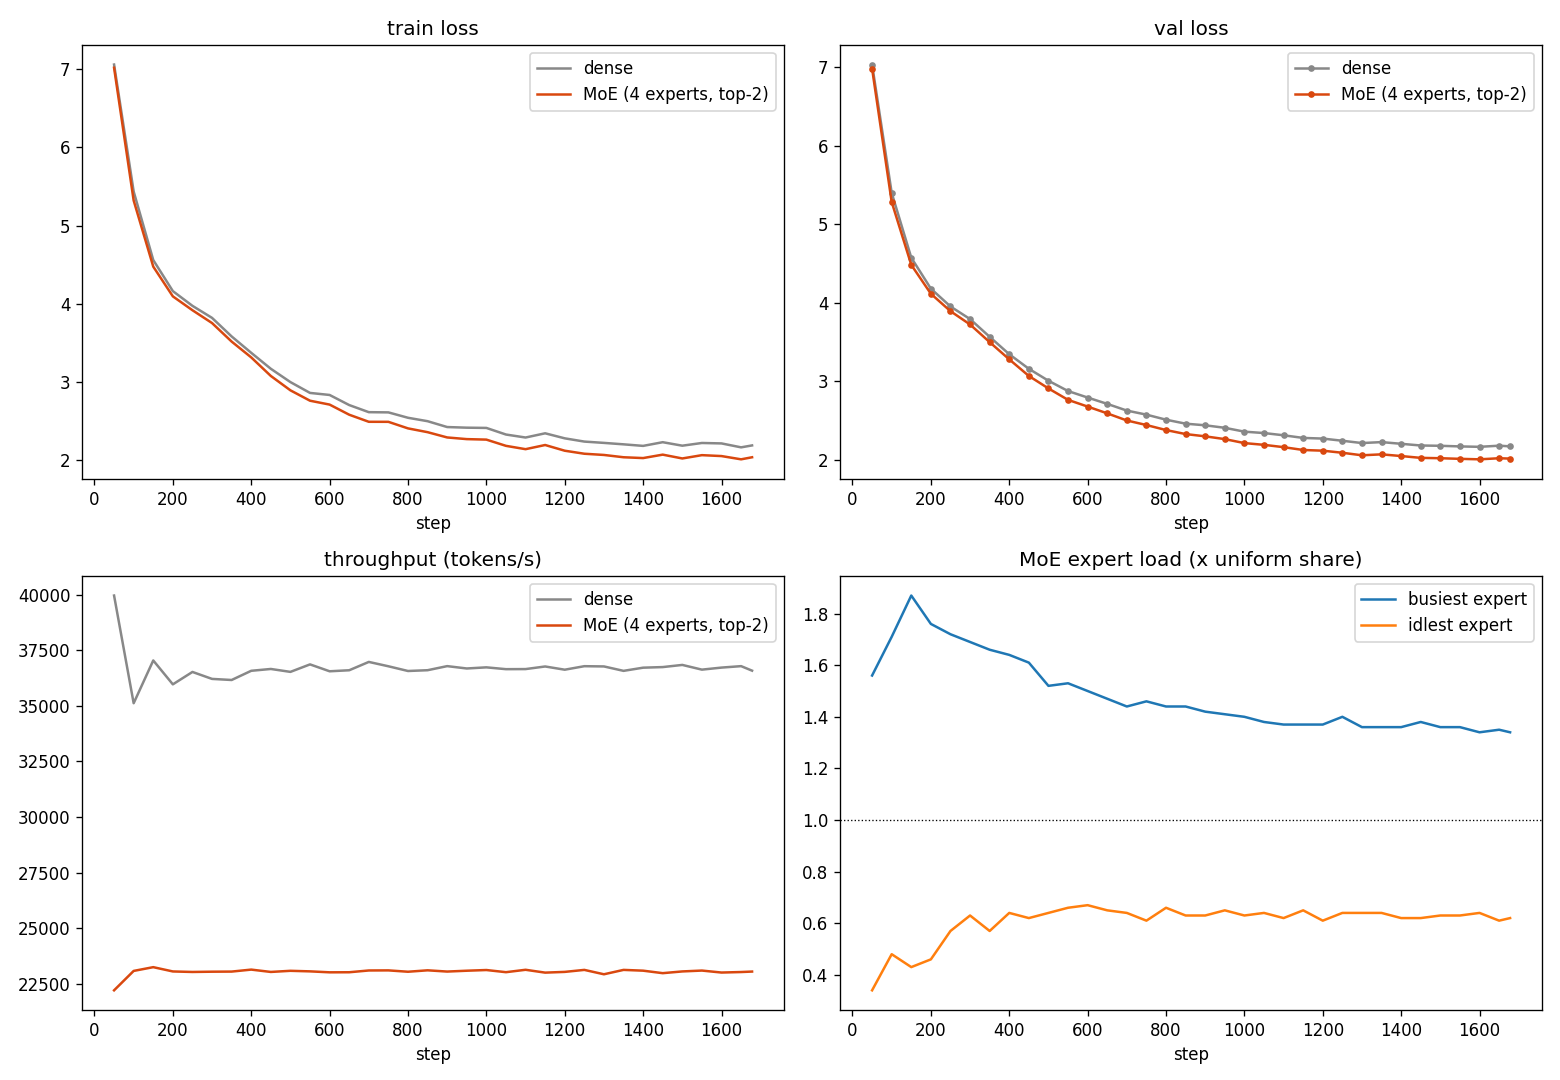

In [11]:
import glob
from IPython.display import Image, display
from plot_moe import compare

# newest metrics file of each run (files are timestamped per run)
dense_csv = sorted(glob.glob("/kaggle/working/metrics_zero3_*.csv"))[-1]
moe_csv = sorted(glob.glob("/kaggle/working/metrics_moe_*.csv"))[-1]
print(dense_csv, moe_csv, sep="\n")
display(Image(compare(dense_csv, moe_csv, "/kaggle/working/plots")))

In [12]:
import pandas as pd

# final row of each run, side by side
last = lambda p: pd.read_csv(p).iloc[-1]
pd.DataFrame({"dense": last(dense_csv), "moe": last(moe_csv)})

,dense,moe
alloc_mb,1.800000e+02,4.760000e+02
aux_loss,NaN,1.034700e+00
gpu_total_mb,1.563600e+04,1.563600e+04
gpu_used_mb,8.113000e+03,1.531000e+04
grad_norm,4.600000e-01,3.600000e-01
load_max,NaN,1.340000e+00
load_min,NaN,6.200000e-01
loss,2.184400e+00,2.032700e+00
loss_tokens,5.476939e+07,5.476939e+07
lr,3.000000e-05,3.000000e-05
